# Scrap-EAF steel NPV simulation

Run the Monte Carlo simulation for Scrap-EAF steel and visualize its total NPV, LNM, and LCOS (steel LCOX) distributions. The NPV summary also reports the number and share of simulations with non-negative versus negative NPV.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from steel.steel_npv_monte_carlo import (
    DEFAULT_RANDOM_SEED,
    DEFAULT_RETROFIT_BAU_MODE,
    DEFAULT_SAMPLE_SIZE,
    simulate_steel_results,
)

from npv_summary import summarize_metric_signs
from npv_summary_plots import plot_financial_metric_distribution


In [2]:
TECHNOLOGY = "scrap_eaf"
SAMPLE_SIZE = DEFAULT_SAMPLE_SIZE
RANDOM_SEED = DEFAULT_RANDOM_SEED
RETROFIT_BAU_MODE = DEFAULT_RETROFIT_BAU_MODE

results_by_technology = simulate_steel_results(
    sample_size=SAMPLE_SIZE,
    random_seed=RANDOM_SEED,
    technologies=(TECHNOLOGY,),
    retrofit_bau_mode=RETROFIT_BAU_MODE,
)
simulation = results_by_technology[TECHNOLOGY]
results = pd.DataFrame(simulation)
results.head()


,run_id,technology,technology_type,retrofit_bau_mode,annual_output_tcs,lifetime_years,capex_eur_per_tcs,fixed_opex_eur_per_tcs,variable_opex_eur_per_tcs,fuel_type,...,annual_electricity_cost_eur,annual_transport_and_storage_cost_eur,annual_emissions_cost_eur,annual_total_cost_eur,annual_net_cash_flow_eur,npv_eur,discounted_lifetime_output_tcs,present_value_total_cost_eur,lcos_eur_per_tcs,levelized_net_margin_eur_per_tcs
0,0,scrap_eaf,absolute,not_applicable,1000000.0,20.0,294.590944,19.756495,492.791319,charcoal,...,6.901306e+07,0.0,2.699010e+06,5.926029e+08,-1.426029e+08,-1.694687e+09,9.818147e+06,6.112853e+09,622.607627,-172.607627
1,1,scrap_eaf,absolute,not_applicable,1000000.0,20.0,326.882595,18.364798,507.690530,charcoal,...,9.821825e+07,0.0,1.903101e+06,6.345197e+08,-1.845197e+08,-2.138524e+09,9.818147e+06,6.556690e+09,667.813394,-217.813394
2,2,scrap_eaf,absolute,not_applicable,1000000.0,20.0,263.528507,20.905530,508.642483,charcoal,...,1.299626e+08,0.0,1.716202e+06,6.695698e+08,-2.195698e+08,-2.419297e+09,9.818147e+06,6.837464e+09,696.410763,-246.410763
3,3,scrap_eaf,absolute,not_applicable,1000000.0,20.0,268.658293,21.215952,486.947143,charcoal,...,1.298128e+08,0.0,2.919519e+06,6.492385e+08,-1.992385e+08,-2.224811e+09,9.818147e+06,6.642977e+09,676.601904,-226.601904
4,4,scrap_eaf,absolute,not_applicable,1000000.0,20.0,399.670069,18.990074,543.257699,charcoal,...,1.171904e+08,0.0,2.397480e+06,6.901787e+08,-2.401787e+08,-2.757780e+09,9.818147e+06,7.175946e+09,730.885955,-280.885955


In [3]:
npv_million_eur = results["npv_eur"] / 1_000_000
lcos_eur_per_tcs = results["lcos_eur_per_tcs"]
levelized_net_margin_eur_per_tcs = results["levelized_net_margin_eur_per_tcs"]

summary = pd.concat(
    [
        npv_million_eur.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "NPV million EUR"
        ),
        lcos_eur_per_tcs.describe(percentiles=[0.05, 0.5, 0.95]).rename(
            "LCOS EUR/tCS"
        ),
        levelized_net_margin_eur_per_tcs.describe(
            percentiles=[0.05, 0.5, 0.95]
        ).rename("Levelized net margin EUR/tCS"),
    ],
    axis=1,
)

npv_signs = summarize_metric_signs(npv_million_eur)
npv_sign_summary = pd.DataFrame(
    {
        "NPV category": ["Non-negative (NPV >= 0)", "Negative (NPV < 0)"],
        "Simulation count": [
            npv_signs["non_negative_count"],
            npv_signs["negative_count"],
        ],
        "Simulation share": [
            npv_signs["non_negative_share"],
            1.0 - npv_signs["non_negative_share"],
        ],
    }
)

display(summary)
display(npv_sign_summary)


,NPV million EUR,LCOS EUR/tCS,Levelized net margin EUR/tCS
count,100000.000000,100000.000000,100000.000000
mean,-2395.154767,693.951804,-243.951804
std,400.736515,40.815899,40.815899
min,-3773.220278,566.956844,-384.310820
5%,-3092.181770,629.534742,-314.945543
50%,-2374.567371,691.854932,-241.854932
95%,-1762.698561,764.945543,-179.534742
max,-1148.299537,834.310820,-116.956844


,NPV category,Simulation count,Simulation share
0,Non-negative (NPV >= 0),0,0.0
1,Negative (NPV < 0),100000,1.0


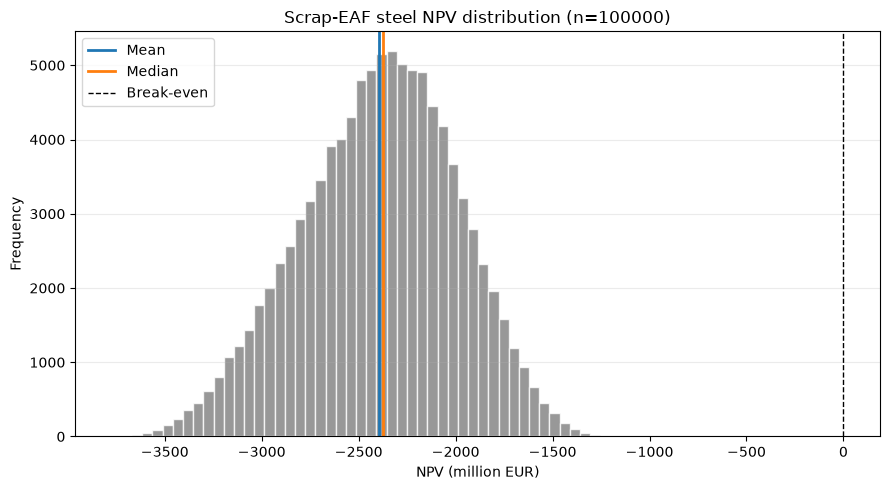

In [4]:
plot_financial_metric_distribution(
    npv_million_eur,
    title=f"Scrap-EAF steel NPV distribution (n={SAMPLE_SIZE})",
    x_axis_label="NPV (million EUR)",
    color="tab:gray",
    show_break_even=True,
)
plt.show()


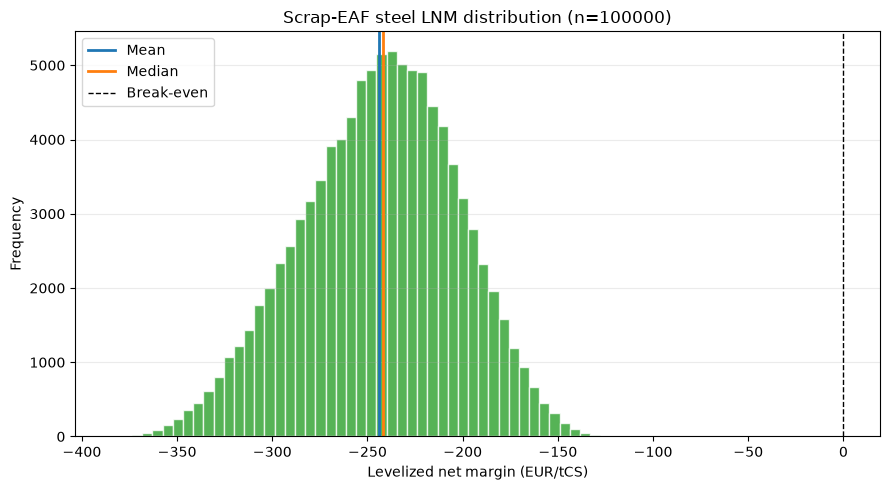

In [5]:
plot_financial_metric_distribution(
    levelized_net_margin_eur_per_tcs,
    title=f"Scrap-EAF steel LNM distribution (n={SAMPLE_SIZE})",
    x_axis_label="Levelized net margin (EUR/tCS)",
    color="tab:green",
    show_break_even=True,
)
plt.show()


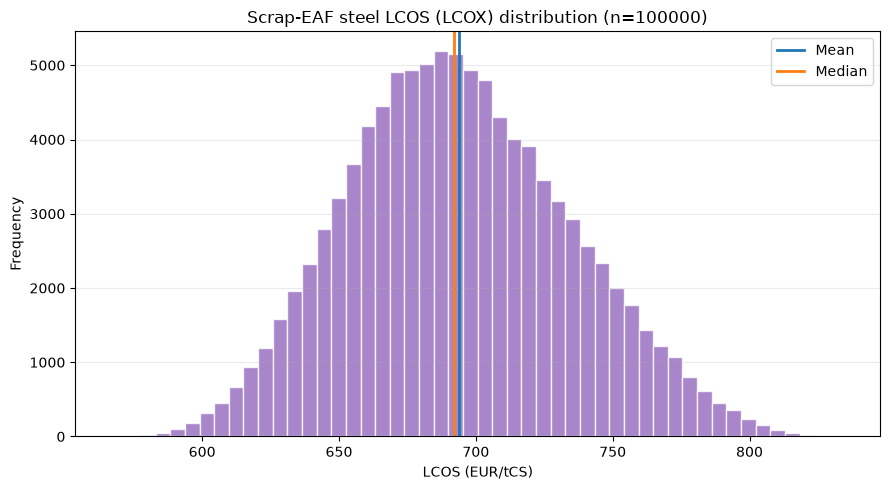

In [6]:
plot_financial_metric_distribution(
    lcos_eur_per_tcs,
    title=f"Scrap-EAF steel LCOS (LCOX) distribution (n={SAMPLE_SIZE})",
    x_axis_label="LCOS (EUR/tCS)",
    color="tab:purple",
)
plt.show()


In [7]:
annual_components = results[
    [
        "annual_revenue_eur",
        "annual_fixed_opex_eur",
        "annual_variable_opex_eur",
        "annual_fuel_cost_eur",
        "annual_electricity_cost_eur",
        "annual_emissions_cost_eur",
        "annual_net_cash_flow_eur"
    ]
] / 1_000_000

annual_components.mean().rename("Mean annual value, million EUR")


annual_revenue_eur             450.000000
annual_fixed_opex_eur           19.667745
annual_variable_opex_eur       507.189676
annual_fuel_cost_eur             8.343000
annual_electricity_cost_eur    123.485162
annual_emissions_cost_eur        2.399976
annual_net_cash_flow_eur      -211.085558
Name: Mean annual value, million EUR, dtype: float64